# Testing BaselineGCN - 2 layer conv nn on atom features only with relu activation functions

[18:26:50] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[18:26:50] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[18:26:50] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[18:26:50] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

num_node_features = 152
num_y_ATs = 75
FULL DATASET:


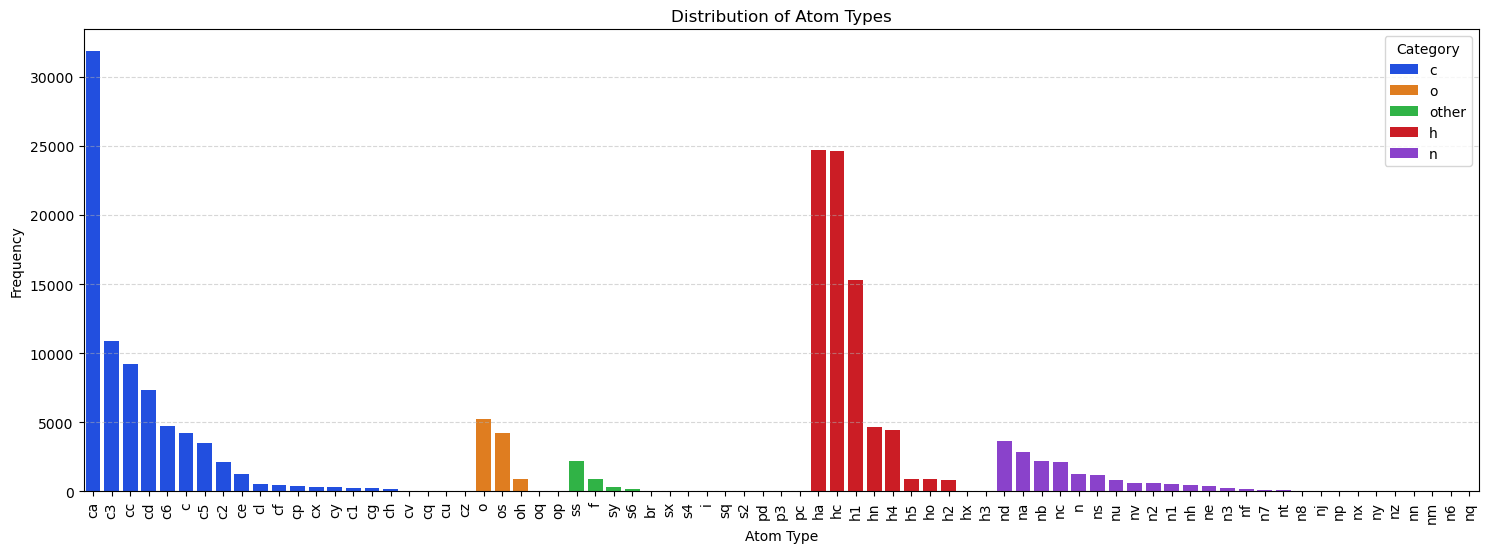

BaselineGCN - Number of parameters: 379467


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.7579 | Val Loss: 0.7697
Epoch - 20: Train Loss: 0.6699 | Val Loss: 0.7015


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.6247 | Val Loss: 0.6351
Epoch - 20: Train Loss: 0.6053 | Val Loss: 0.6175


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.5857 | Val Loss: 0.6088
Epoch - 20: Train Loss: 0.5758 | Val Loss: 0.5910


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.5647 | Val Loss: 0.5809
Epoch - 20: Train Loss: 0.5585 | Val Loss: 0.5796


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.5531 | Val Loss: 0.5581
Epoch - 20: Train Loss: 0.5469 | Val Loss: 0.5645


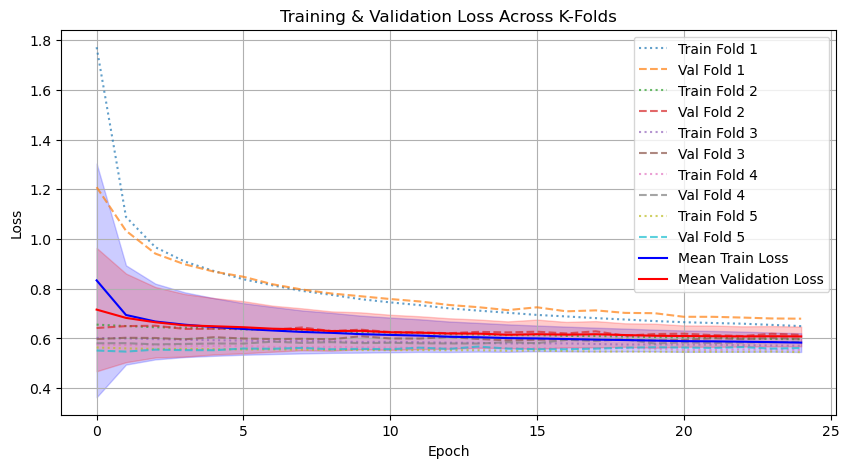

Evaluation Metrics: {'Accuracy': 0.7695934959349594, 'F1-score': 0.7517846662788733}


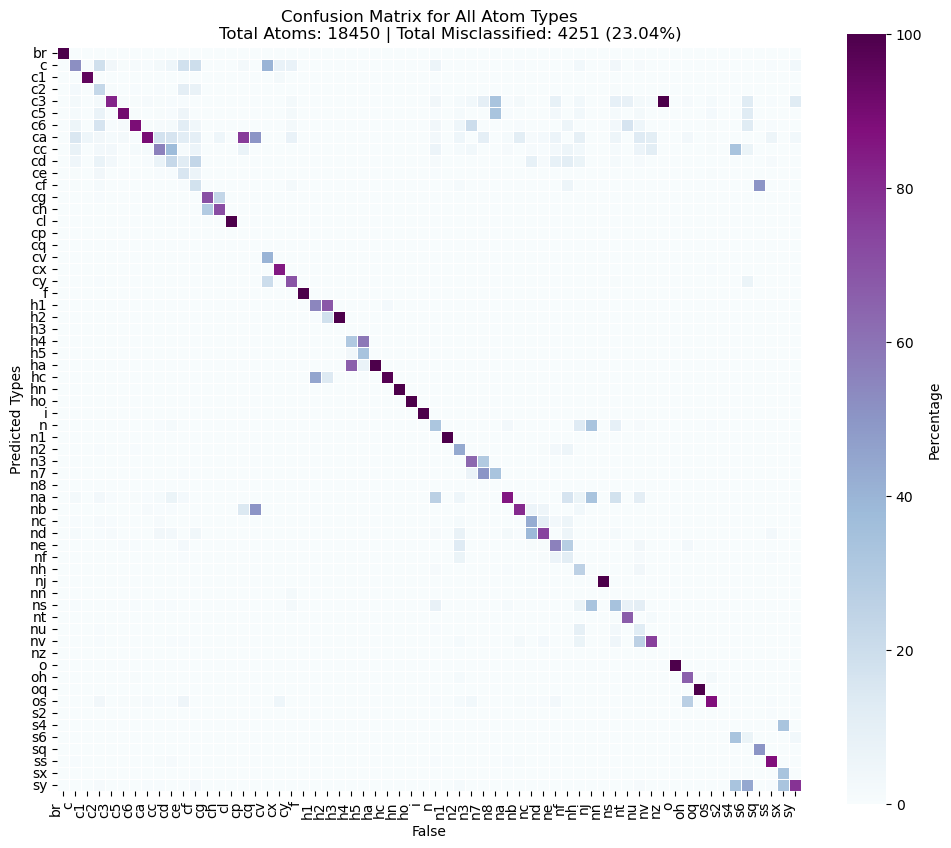

In [1]:
from atoMLtype.GNN.GNNmodel import GNNTrainer, BaselineGCN, BaselineGAT
from atoMLtype.GNN.GNNdataset import GNNdataset
from atoMLtype.utils.metrics import plot_atom_distribution, plot_full_confusion_matrix, plot_category_confusion_matrix
from torch.utils.data import random_split
import numpy as np

# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
gnn_test_dataset = GNNdataset(sdf_path, json_labels)
num_node_feat = gnn_test_dataset[0].x.shape[1]
num_y_ATs = len(set(gnn_test_dataset.all_labels))

print(f"num_node_features = {num_node_feat}")
print(f"num_y_ATs = {num_y_ATs}")


# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(gnn_test_dataset))
test_size = len(gnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(gnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(gnn_test_dataset.all_labels))

# Initialize BaselineGCN for classification
model = BaselineGCN(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512)
trainer = GNNTrainer(model, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=25, k_folds=5, task="classification", random_seed=21)
trainer.train()
metrics = trainer.evaluate_model(test_dataset)

y_true_labels, y_pred_labels = trainer.predict(test_dataset)

plot_full_confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)


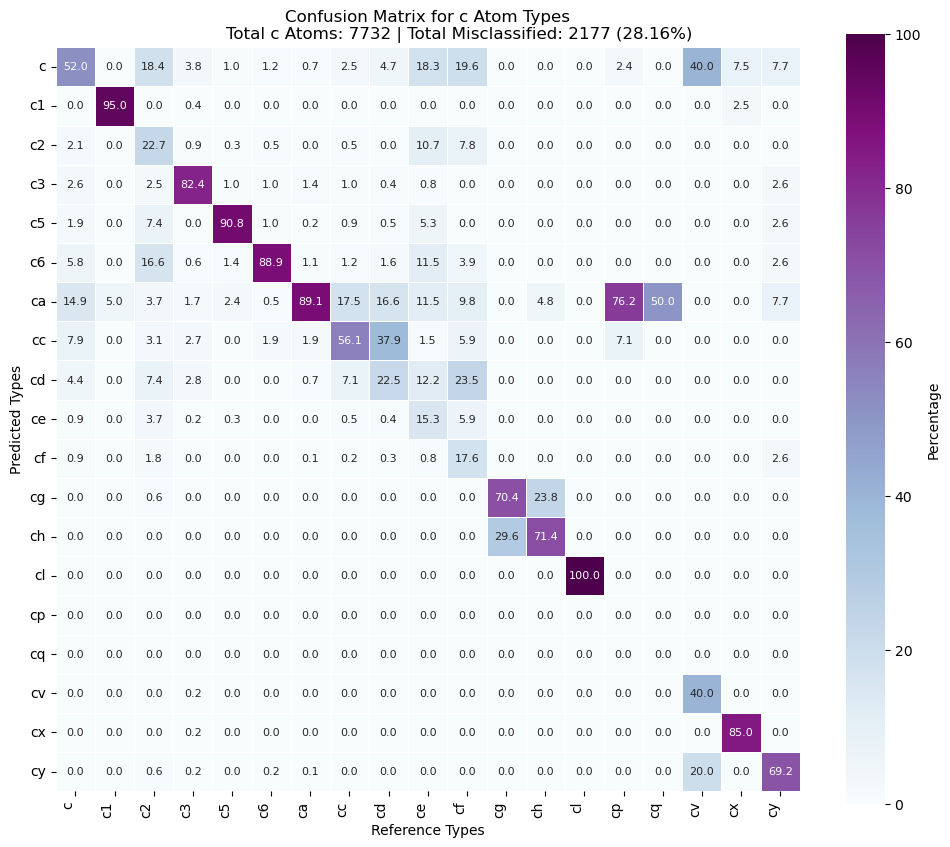

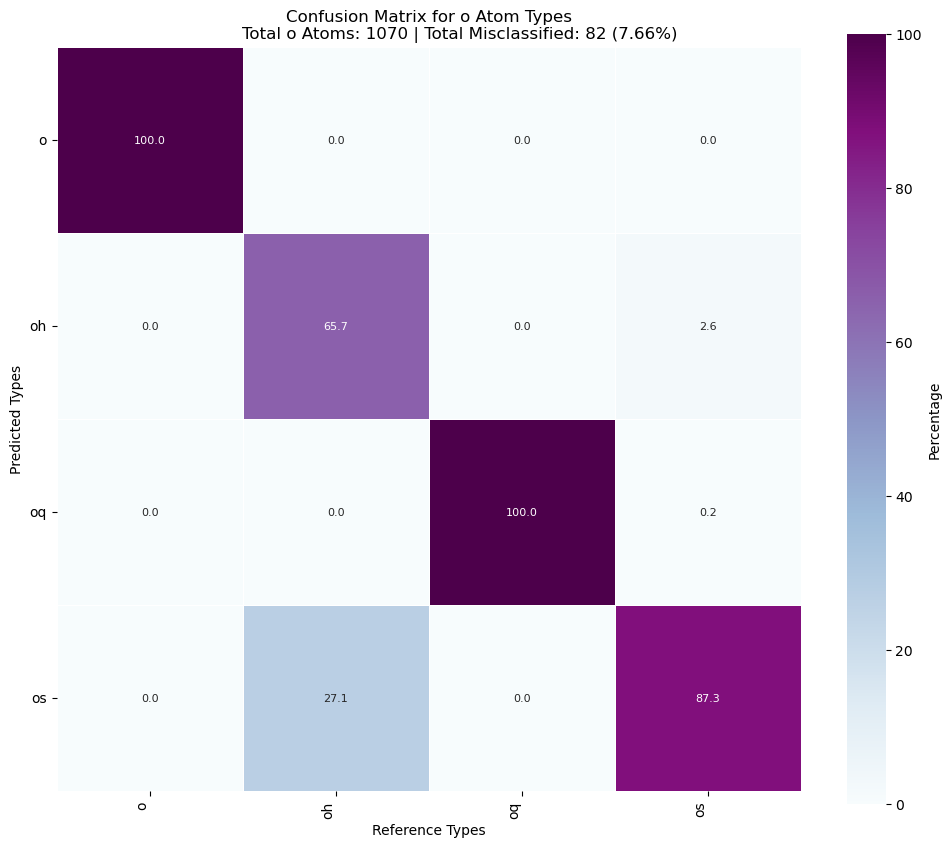

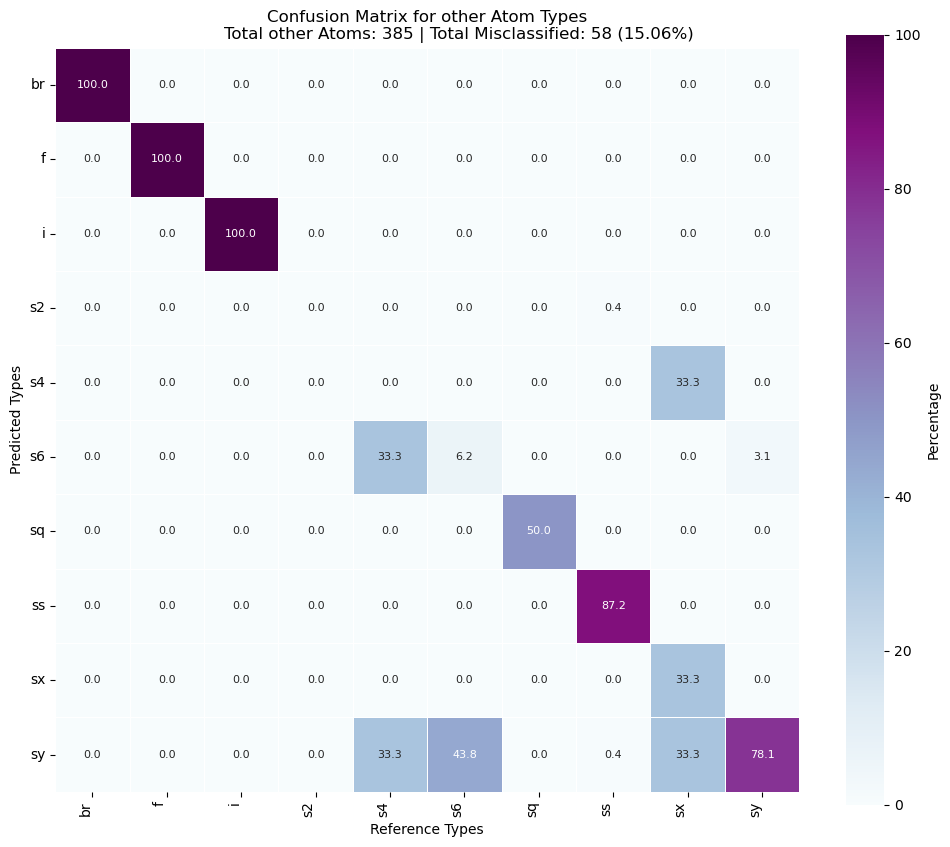

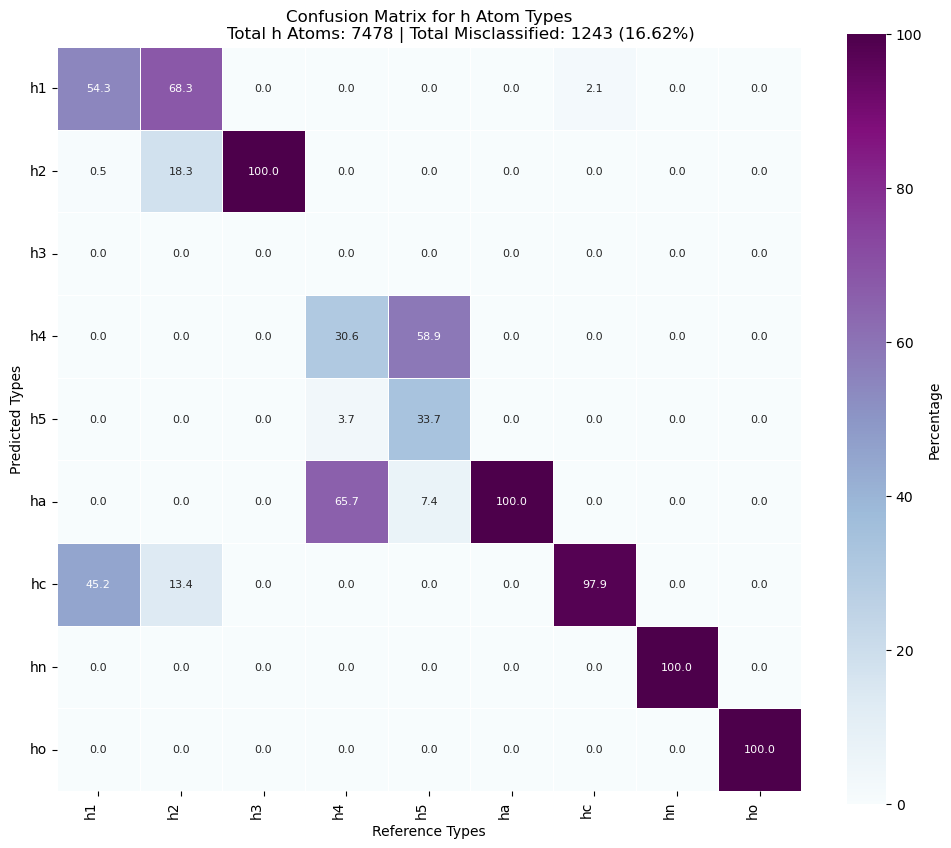

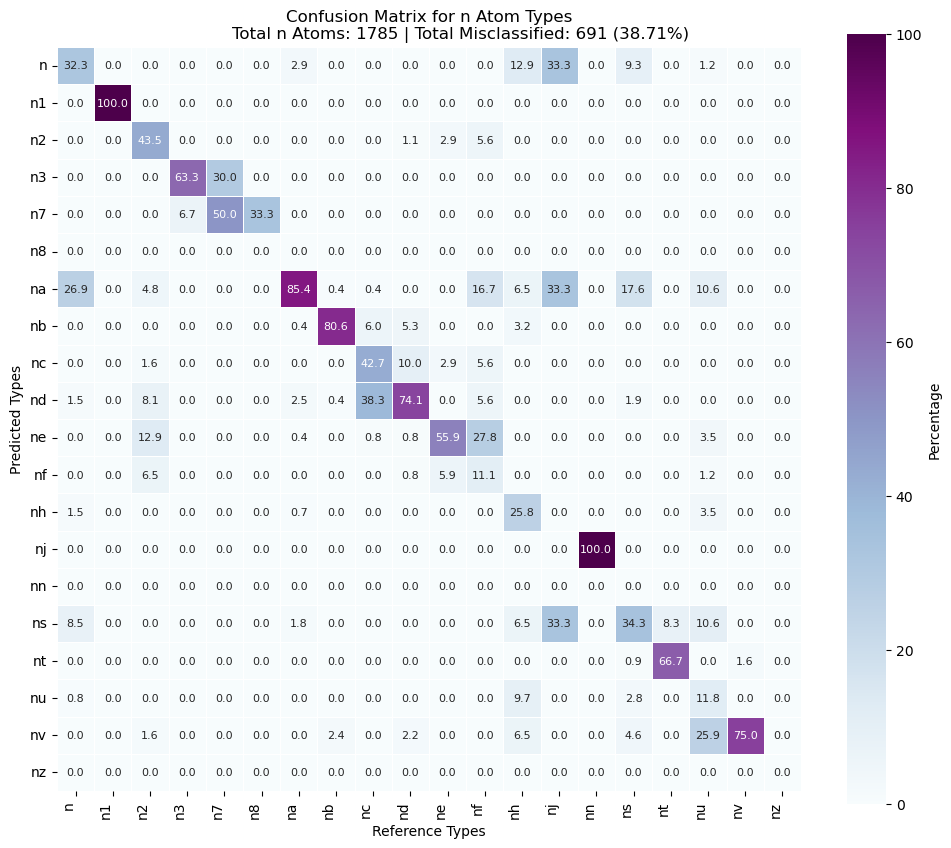

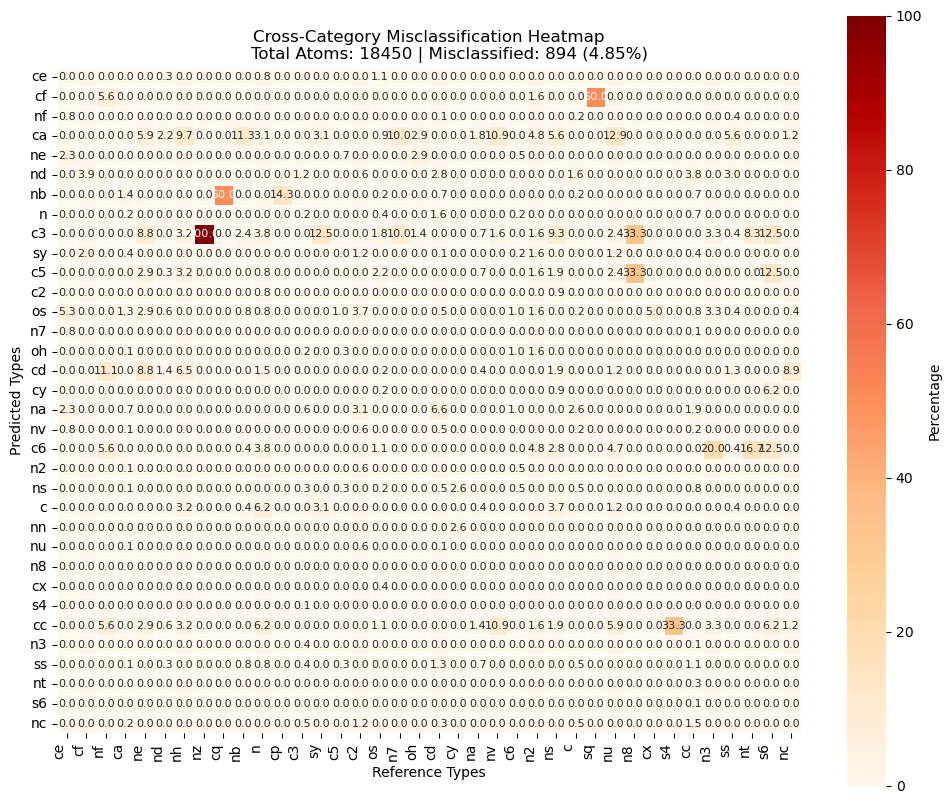

In [2]:
from atoMLtype.utils.metrics import plot_detailed_cross_category_confusion

plot_category_confusion_matrix(y_pred=y_pred_labels, y_true=y_true_labels)

plot_detailed_cross_category_confusion(y_pred=y_pred_labels, y_true=y_true_labels)

# Testing BaselineGAT - 2 layer Graph Convulutions with attention mechanism nn on atom features only with elu activation functions

BaselineGAT - Number of parameters: 1406027


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.5640 | Val Loss: 0.5628
Epoch - 20: Train Loss: 0.5056 | Val Loss: 0.5359


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.4797 | Val Loss: 0.4788
Epoch - 20: Train Loss: 0.4734 | Val Loss: 0.4788


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.4605 | Val Loss: 0.4703
Epoch - 20: Train Loss: 0.4539 | Val Loss: 0.4673


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.4485 | Val Loss: 0.4682
Epoch - 20: Train Loss: 0.4430 | Val Loss: 0.4635


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.4477 | Val Loss: 0.4620
Epoch - 20: Train Loss: 0.4435 | Val Loss: 0.4550


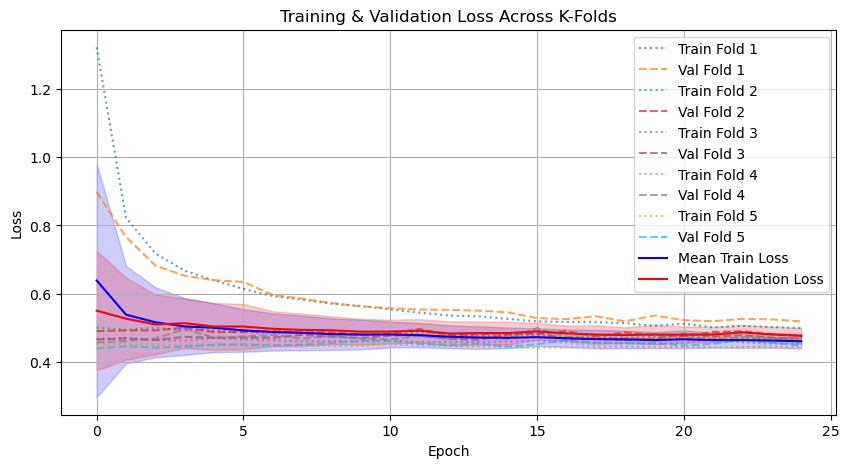

Evaluation Metrics: {'Accuracy': 0.8130081300813008, 'F1-score': 0.8000410047694447}


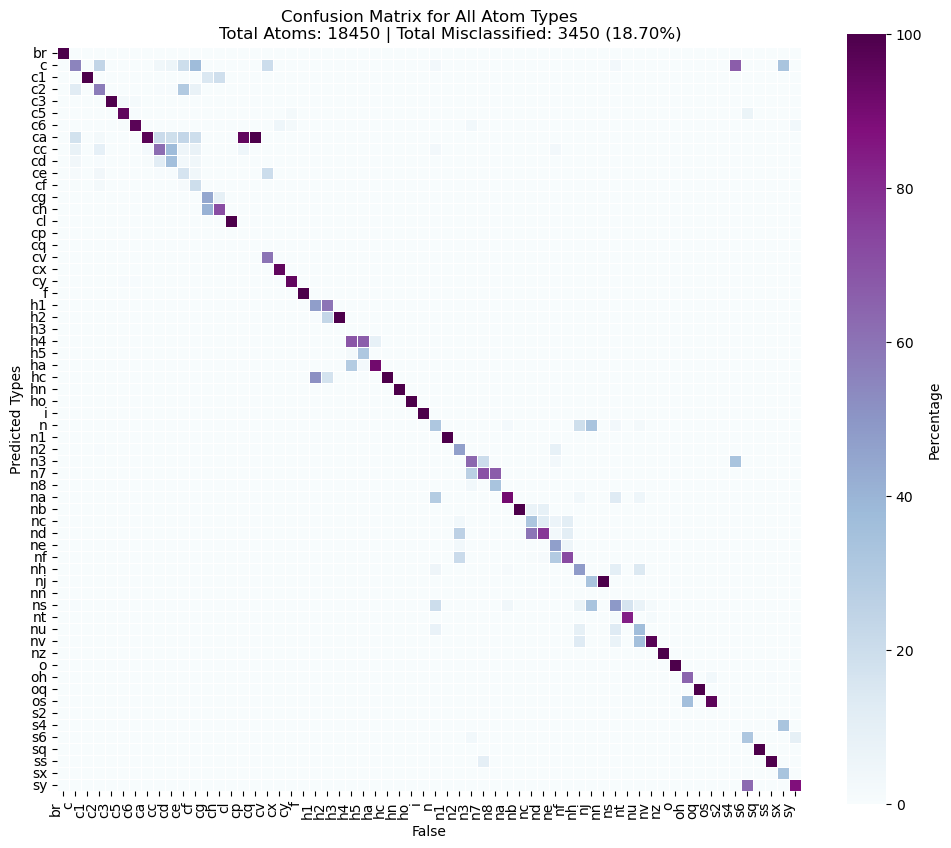

In [3]:
# Initialize baselineGNN for classification
model_GAT = BaselineGAT(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512, heads=4)
trainer_GAT = GNNTrainer(model_GAT, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=25, k_folds=5, task="classification", random_seed=21)
trainer_GAT.train()
metrics_GAT = trainer_GAT.evaluate_model(test_dataset)

y_true_GAT, y_pred_GAT = trainer_GAT.predict(test_dataset)

plot_full_confusion_matrix(y_true=y_true_GAT, y_pred=y_pred_GAT)


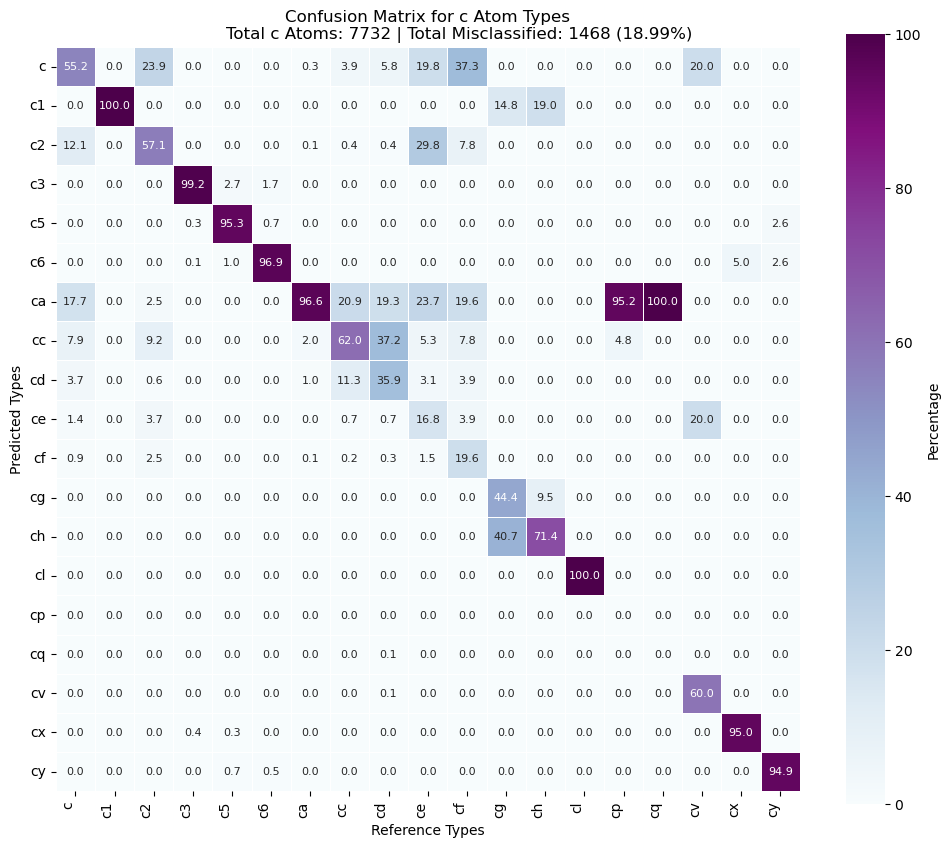

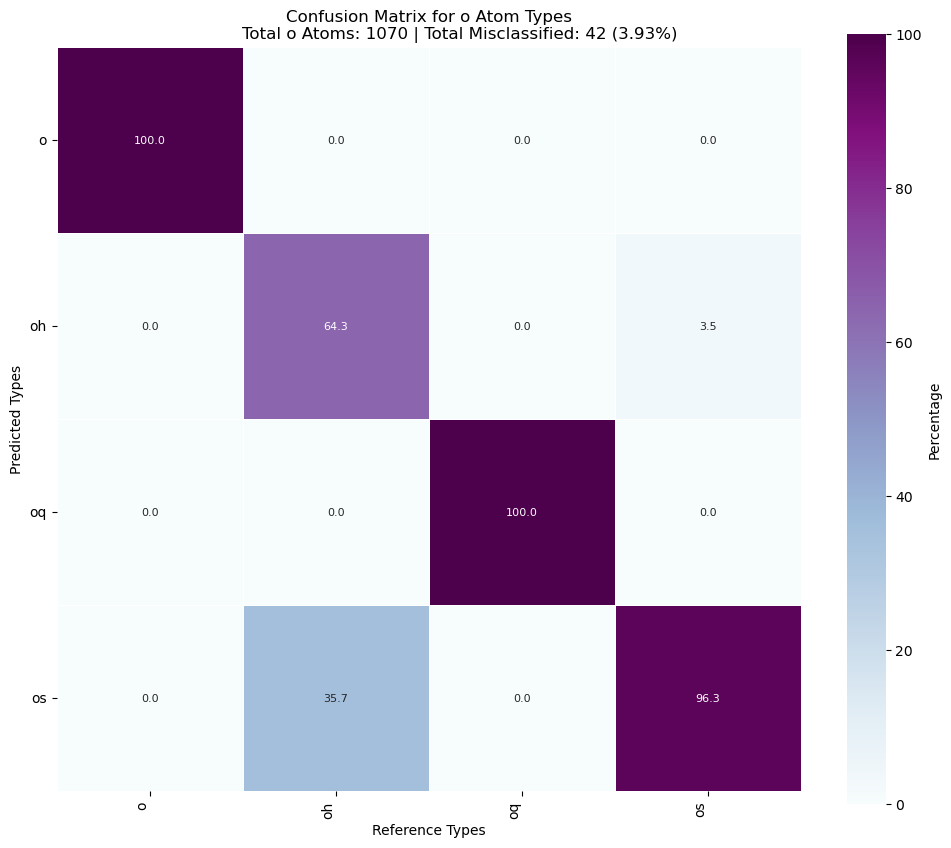

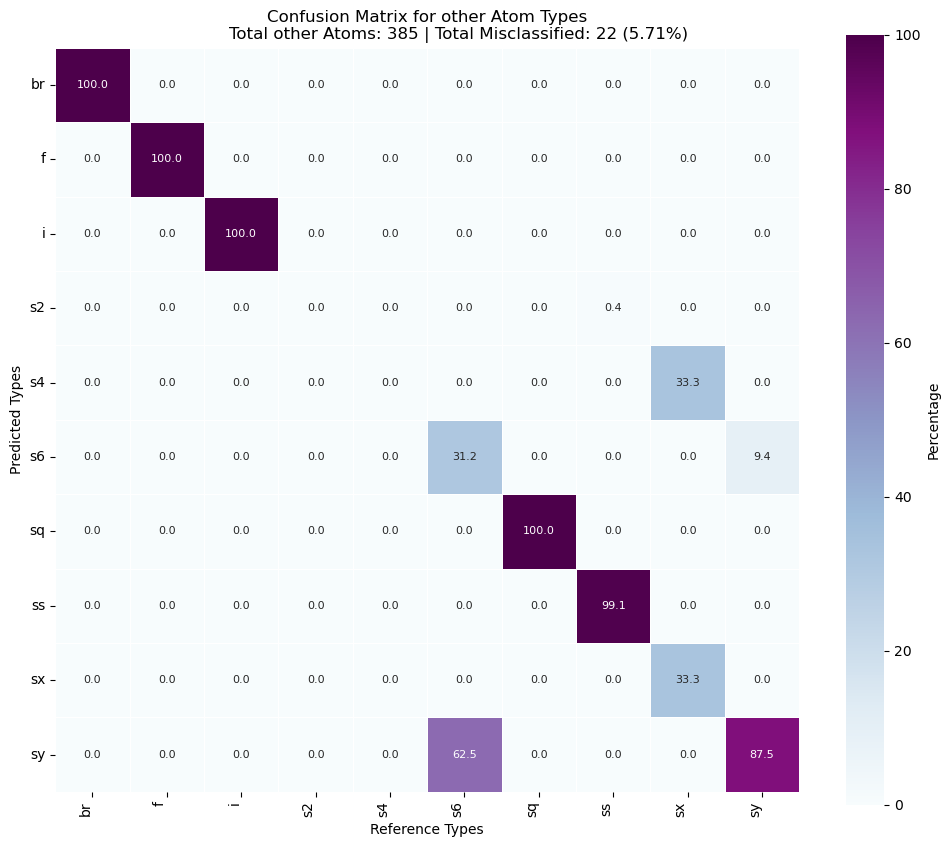

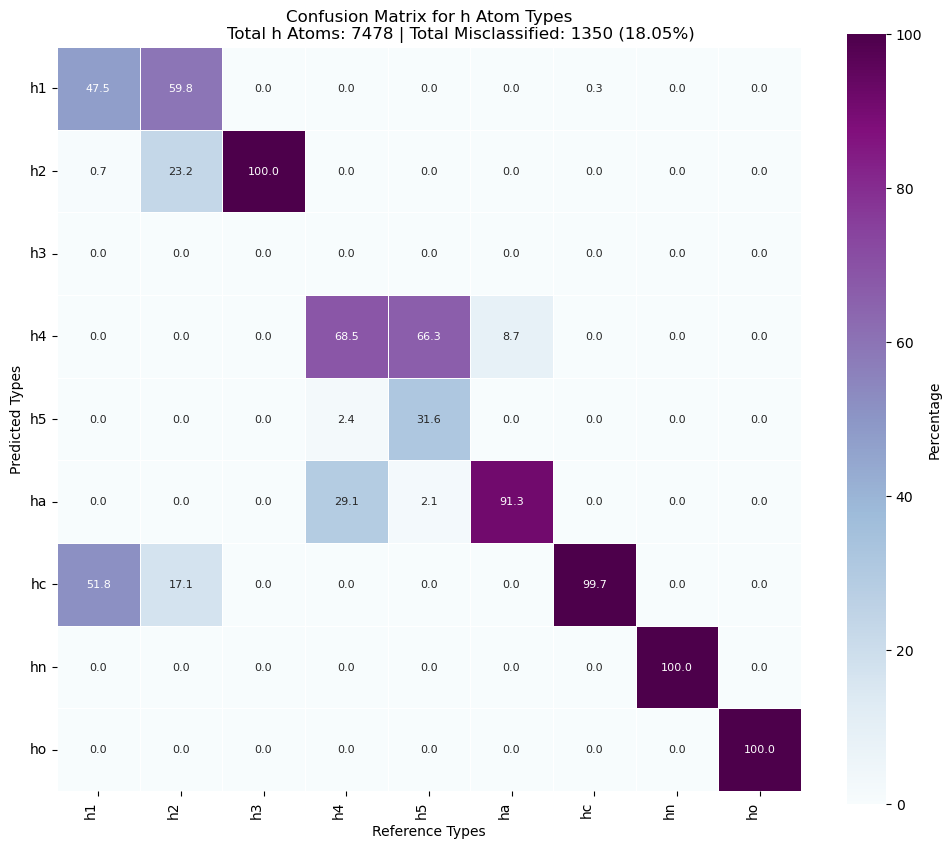

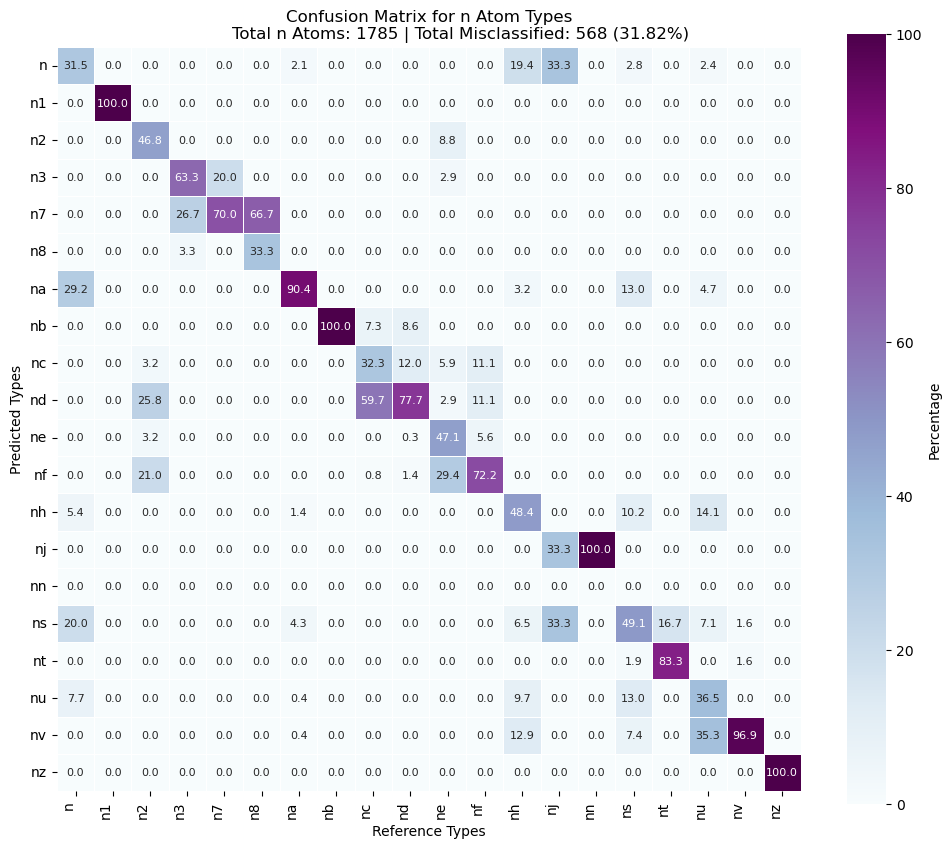

In [4]:
plot_category_confusion_matrix(y_pred=y_pred_GAT, y_true= y_true_GAT)

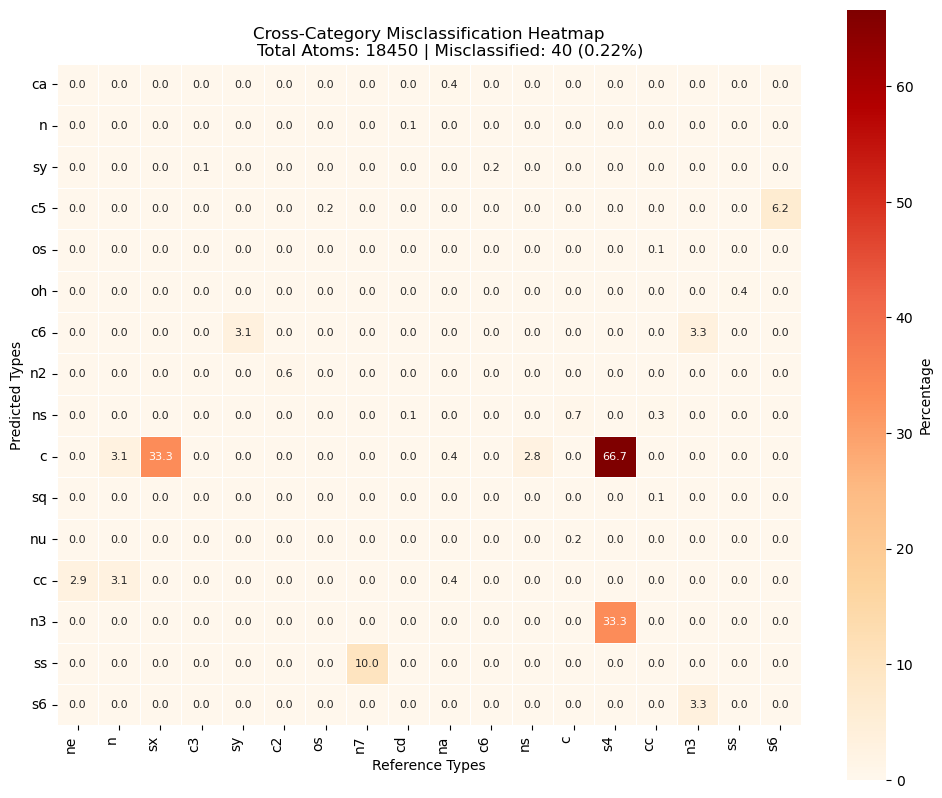

In [5]:
plot_detailed_cross_category_confusion(y_pred=y_pred_GAT, y_true=y_true_GAT)

# Testing GCN_4Layer - 4 layer Graph Conv nn on atom features only with relu activation functions

GCN_4Layer - Number of parameters: 268747


---------KFOLD: 0----------
Epoch - 10: Train Loss: 1.1123 | Val Loss: 1.1239
Epoch - 20: Train Loss: 0.9695 | Val Loss: 1.0012
Epoch - 30: Train Loss: 0.8746 | Val Loss: 0.9300


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.8300 | Val Loss: 0.8181
Epoch - 20: Train Loss: 0.7845 | Val Loss: 0.7911
Epoch - 30: Train Loss: 0.7531 | Val Loss: 0.7885


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.7319 | Val Loss: 0.7607
Epoch - 20: Train Loss: 0.7106 | Val Loss: 0.7545
Epoch - 30: Train Loss: 0.6893 | Val Loss: 0.7320


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.6833 | Val Loss: 0.7075
Epoch - 20: Train Loss: 0.6654 | Val Loss: 0.7141
Epoch - 30: Train Loss: 0.6533 | Val Loss: 0.7161


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.6534 | Val Loss: 0.6512
Epoch - 20: Train Loss: 0.6426 | Val Loss: 0.6739
Epoch - 30: Train Loss: 0.6305 | Val Loss: 0.6682


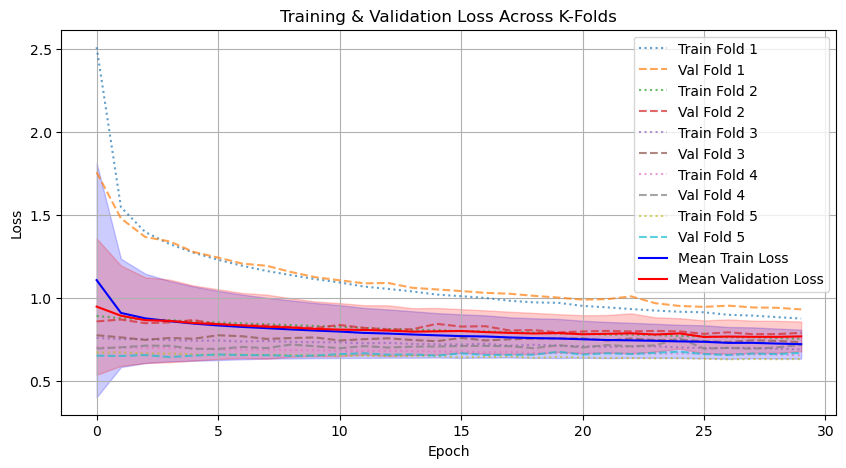

Evaluation Metrics: {'Accuracy': 0.7538753387533875, 'F1-score': 0.7373188080567022}


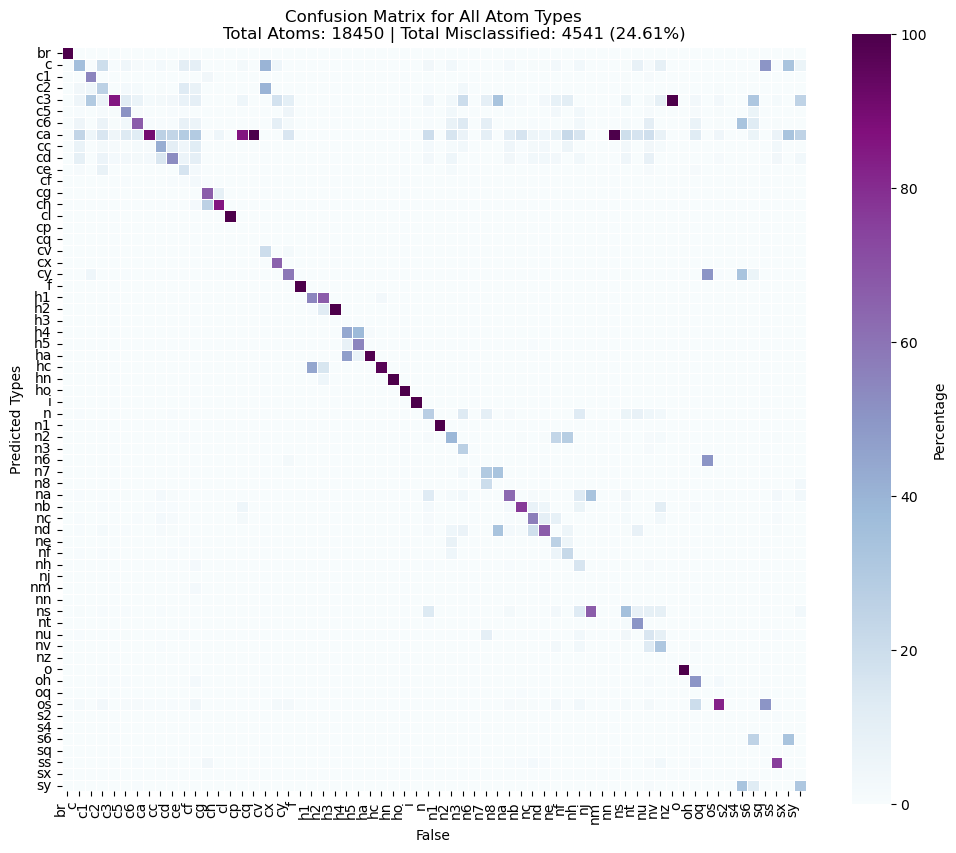

In [6]:
import importlib
import atoMLtype
importlib.reload(atoMLtype.GNN.GNNmodel)
from atoMLtype.GNN.GNNmodel import GCN_4Layer

# Initialize baselineGNN for classification
model_GCN_4Layer = GCN_4Layer(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512)
trainer_GCN_4Layer = GNNTrainer(model_GCN_4Layer, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_GCN_4Layer.train()
metrics_GCN_4Layer = trainer_GCN_4Layer.evaluate_model(test_dataset)

y_true_GCN_4Layer, y_pred_GCN_4Layer = trainer_GCN_4Layer.predict(test_dataset)

plot_full_confusion_matrix(y_true=y_true_GCN_4Layer, y_pred=y_pred_GCN_4Layer)

GAT_4L - Number of parameters: 485643


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.6733 | Val Loss: 0.6915
Epoch - 20: Train Loss: 0.6003 | Val Loss: 0.6316
Epoch - 30: Train Loss: 0.5552 | Val Loss: 0.6070


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.5226 | Val Loss: 0.5396
Epoch - 20: Train Loss: 0.5024 | Val Loss: 0.5540
Epoch - 30: Train Loss: 0.4843 | Val Loss: 0.5256


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.4673 | Val Loss: 0.4949
Epoch - 20: Train Loss: 0.4495 | Val Loss: 0.4970
Epoch - 30: Train Loss: 0.4400 | Val Loss: 0.5018


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.4275 | Val Loss: 0.4638
Epoch - 20: Train Loss: 0.4165 | Val Loss: 0.4829
Epoch - 30: Train Loss: 0.3985 | Val Loss: 0.4922


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.3968 | Val Loss: 0.4210
Epoch - 20: Train Loss: 0.3955 | Val Loss: 0.4417
Epoch - 30: Train Loss: 0.3768 | Val Loss: 0.4370


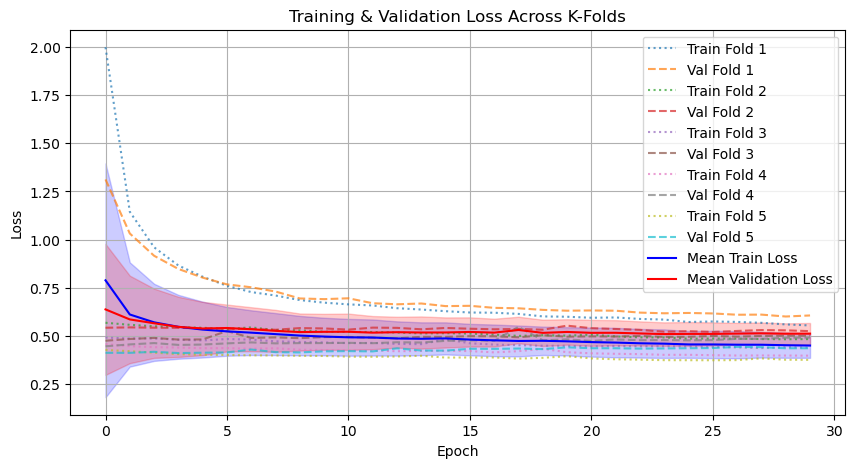

Evaluation Metrics: {'Accuracy': 0.8245528455284553, 'F1-score': 0.812466024025818}


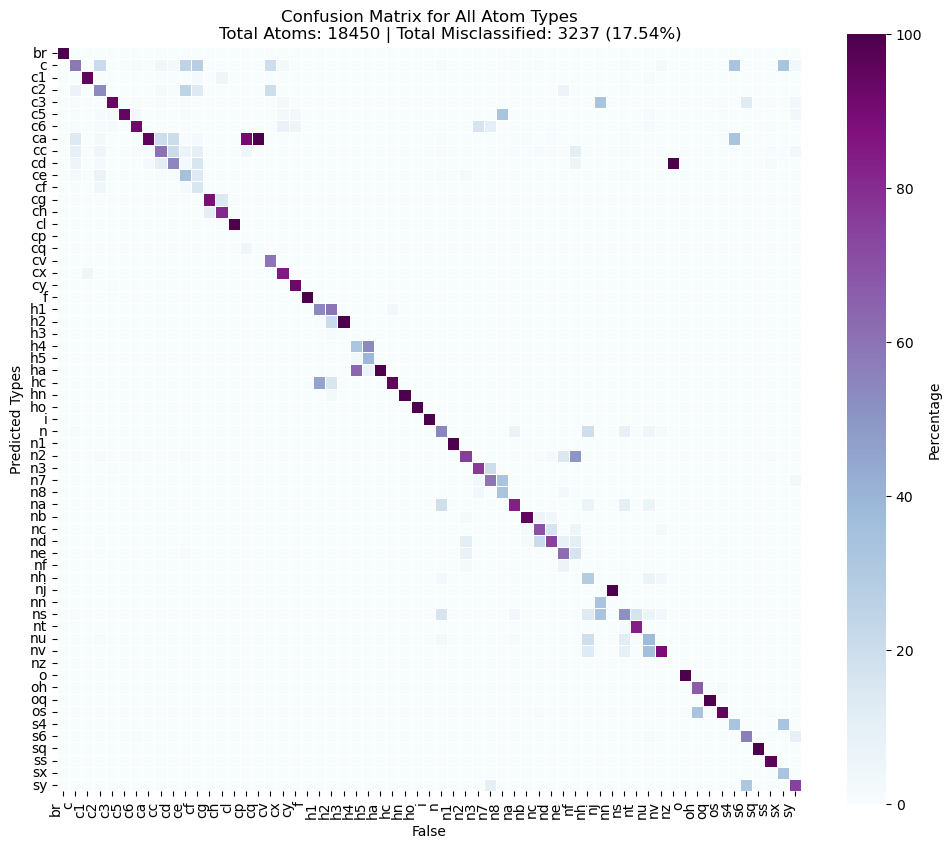

In [7]:
import importlib
import atoMLtype
importlib.reload(atoMLtype.GNN.GNNmodel)
from atoMLtype.GNN.GNNmodel import GAT_4L

# Initialize baselineGNN for classification
model_GAT_4L = GAT_4L(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=128)
trainer_GAT_4L = GNNTrainer(model_GAT_4L, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_GAT_4L.train()
metrics_GAT_4L = trainer_GAT_4L.evaluate_model(test_dataset)

y_true_GAT_4L, y_pred_GAT_4L = trainer_GAT_4L.predict(test_dataset)

plot_full_confusion_matrix(y_true=y_true_GAT_4L, y_pred=y_pred_GAT_4L)

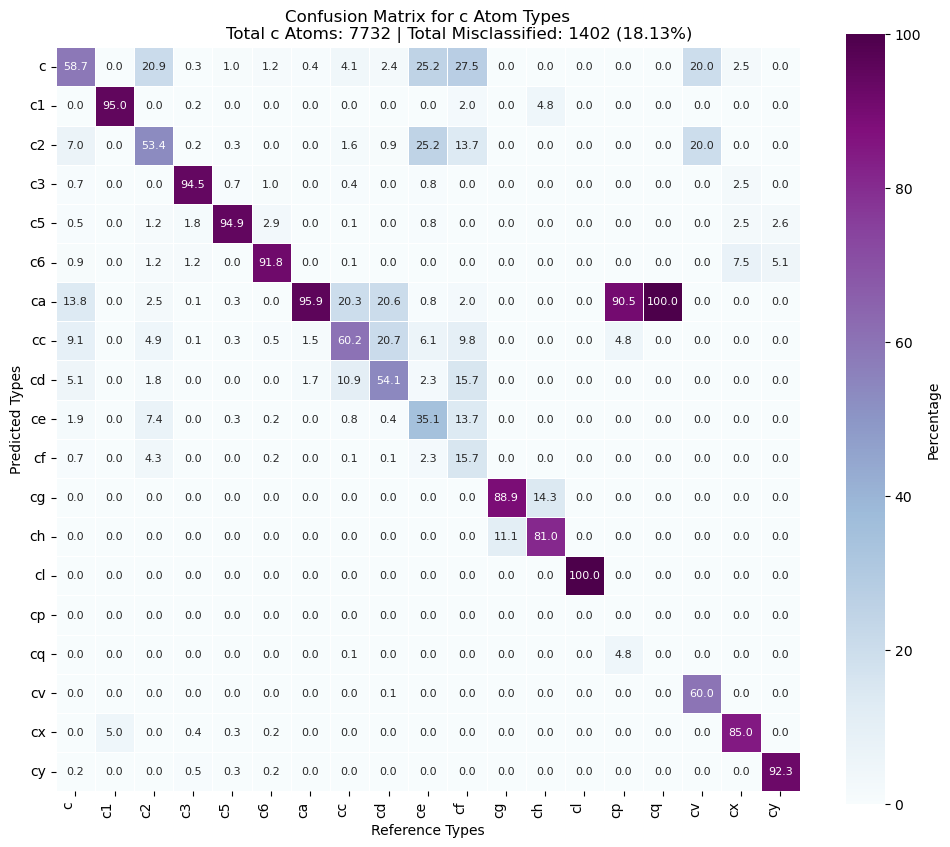

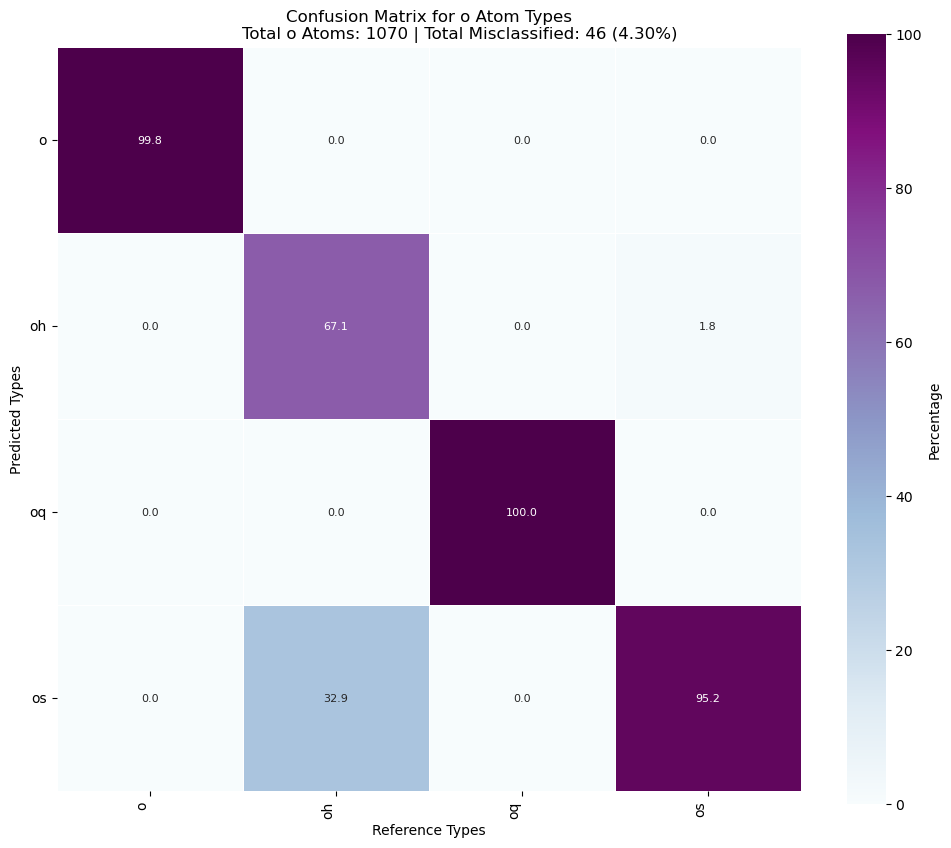

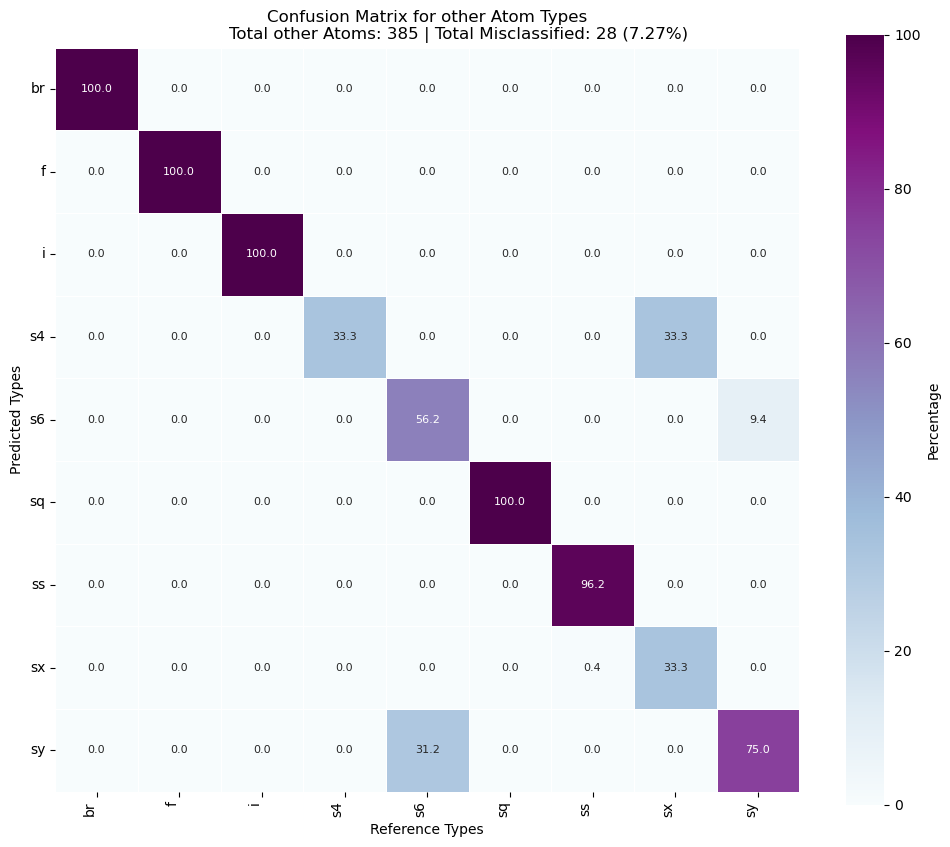

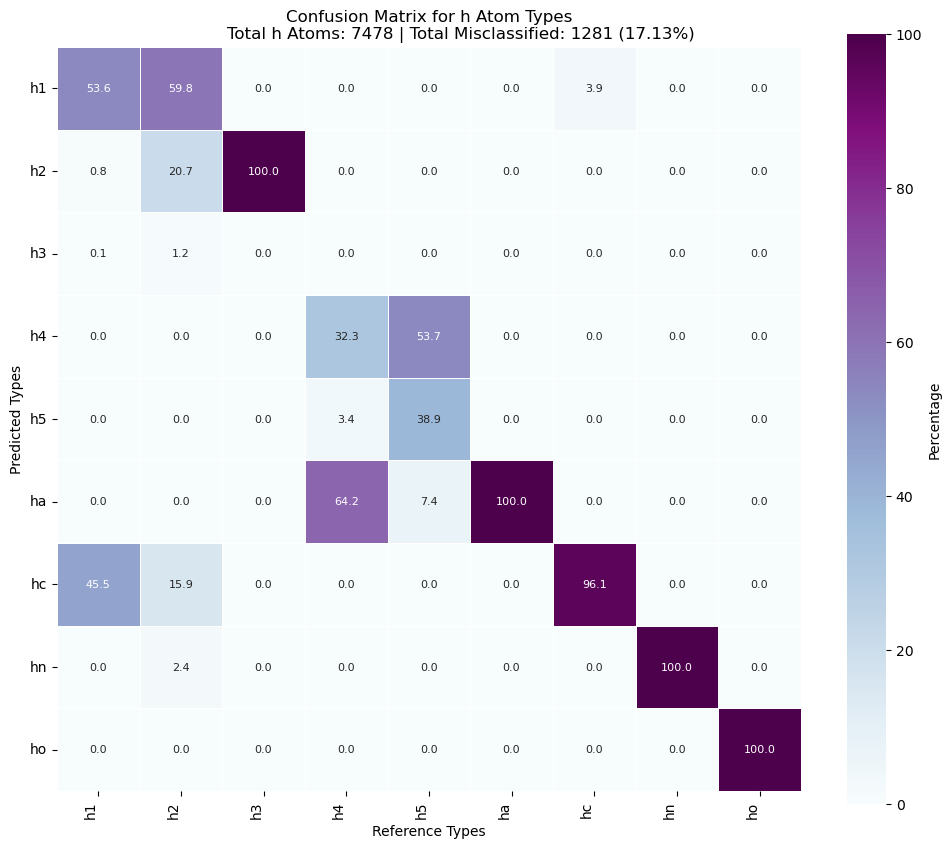

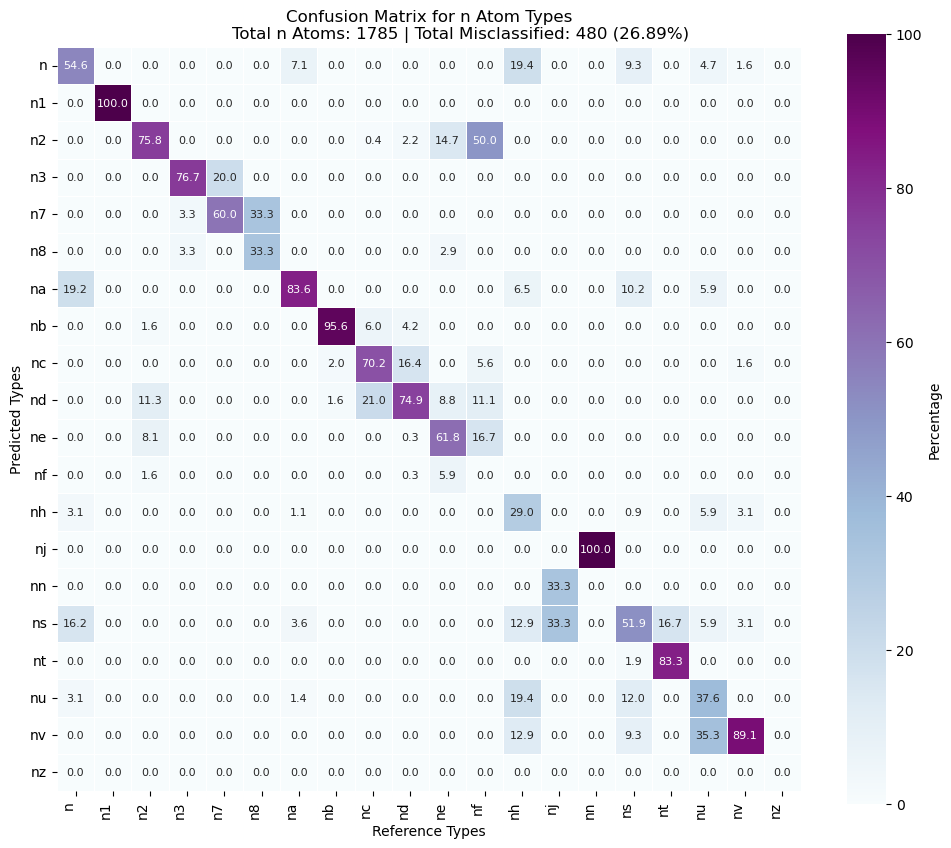

In [8]:
plot_category_confusion_matrix(y_pred=y_pred_GAT_4L, y_true= y_true_GAT_4L)

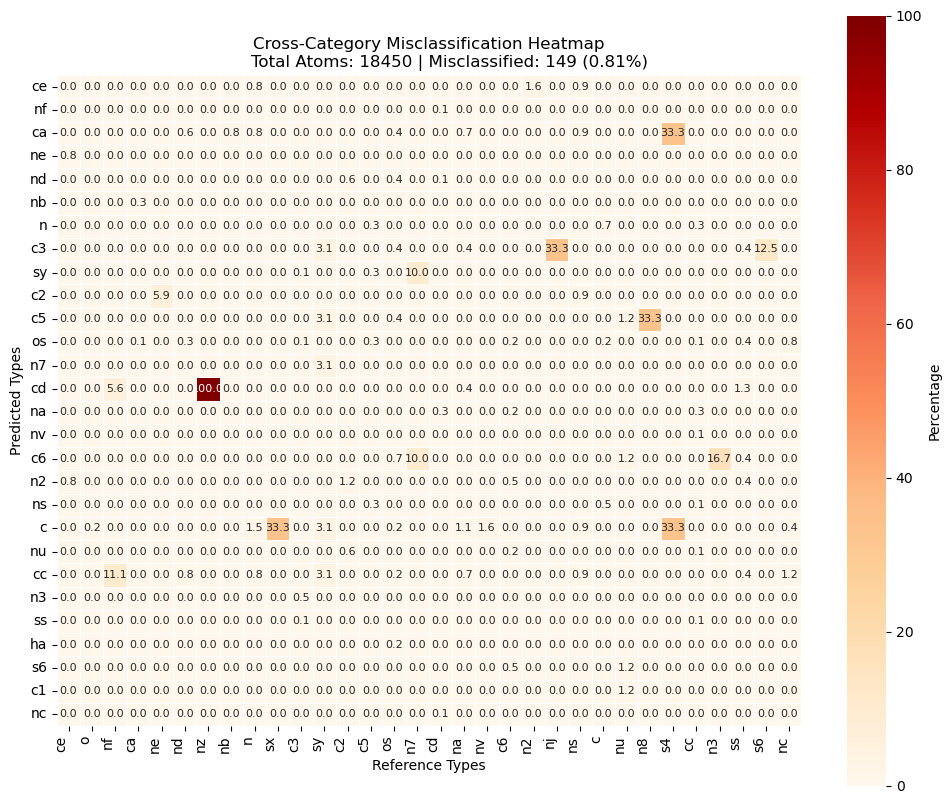

In [9]:
plot_detailed_cross_category_confusion(y_pred=y_pred_GAT_4L, y_true=y_true_GAT_4L)